# Assignment 1

Due end of day Thursday Sept 18th.

## Question 1:
{method, implementation, answer}

Examine the value of sparse matricies by comparing the approximate computational efficiencies of sparse and dense solvers (on the same system). Use the %timeit function to approximate the complexity.

HINT: Refer to the lecture notes on how to generate, store, and apply sparse solvers.

In [7]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# Generate a 200x200 sparse tridiagonal matrix
n = 200
main_diag = np.full(n, 2)
upper_diag = np.full(n - 1, -1)
lower_diag = np.full(n - 1, -1)
A_sparse = diags([lower_diag, main_diag, upper_diag], offsets=[-1, 0, 1], format='csr')

b = np.random.rand(n)

# Convert to dense format for comparison
A_dense = A_sparse.toarray()

print("Timing the Sparse Solver:")
%timeit spsolve(A_sparse, b)

print("\nTiming the Dense Solver:")
%timeit solve(A_dense, b)

Timing the Sparse Solver:
90.5 µs ± 17.2 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)

Timing the Dense Solver:
113 µs ± 1.24 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


## Question 2

Consider the truss:

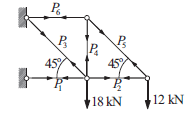


### 2a) Write the linear system for the tensions $P_i$ as equations and in matrix form
{answer}

Method of joints

# Top middle joint force components, net force = 0

Fx=0=P5*cos(45deg)-P6

Fy=0=-P4-P5*sin(45deg)

# Bottom middle joint force components, net force = 18kN down

Fx=0=-P1+P2-P3*cos(45deg)

Fy=18=P3*sin(45deg)+P4

# Bottom right joint force components, net force = 12kN down

Fx=0=-P2-P5*cos(45deg)

Fy=12=P5*sin(45deg)

#Represent as a matrix
Columns are P1 through P6 (P) and set equal to the solution (net forces) of the equations
The rows are the joints with one for each of x and y component

Values in the matrix (A) are coefficients in front of each P in equation

This is equal to the net forces for each joint component (b)

A·P=b

sin(45deg)=cos(45deg)=1/sqrt(2)

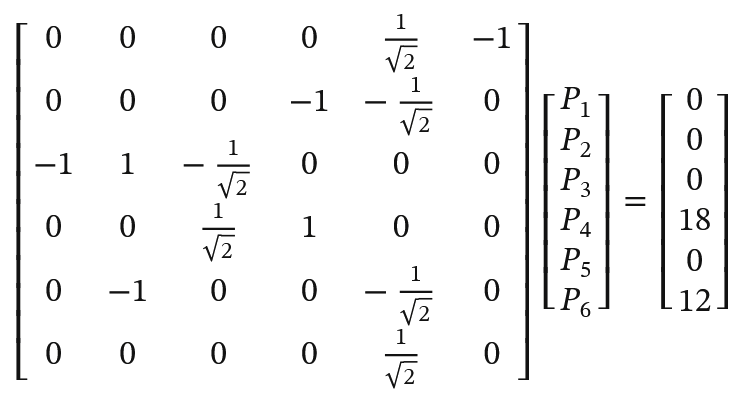

### 2b) Solve for $P_i$ using LU decomposition and substitution.
{method, answer}

LU decomposition - solving a square matric by decomposing it into product of a lower (L) and upper (U) triangular matrix. (L) has 1s on diagonal and info about mulipliers used in elimination and the (U) is the info after elimination. Steps are STORED in L matrix.

This allows expensive O(n^3) to only be performed once and stored in L and re doing same operation with different b matrix is only a O(n^2) operation.

In [8]:
from scipy.linalg import solve

# Define sin(45deg) and cos(45deg)
val_45 = 1 / np.sqrt(2)

# Define the coefficient matrix A
A = np.array([
    [0, 0, 0, 0, val_45, -1],
    [0, 0, 0, -1, -val_45, 0],
    [-1, 1, -val_45, 0, 0, 0],
    [0, 0, val_45, 1, 0, 0],
    [0, -1, 0, 0, -val_45, 0],
    [0, 0, 0, 0, val_45, 0]
])

# Define the force vector b
b = np.array([
    [0],
    [0],
    [0],
    [18],
    [0],
    [12]
])

scipy_solution = solve(A, b)
print("\nSolution using scipy.linalg.solve:\n", scipy_solution)


Solution using scipy.linalg.solve:
 [[-42.        ]
 [-12.        ]
 [ 42.42640687]
 [-12.        ]
 [ 16.97056275]
 [ 12.        ]]


### 2c)  Double the loads (18 kN and 12 kN) and solve for $P_i$ again *without refactoring*.
{answer}

In [9]:
# Re-define the force vector b
b = np.array([
    [0],
    [0],
    [0],
    [18*2],
    [0],
    [12*2]
])

scipy_solution = solve(A, b)
print("\nSolution using scipy.linalg.solve:\n", scipy_solution)


Solution using scipy.linalg.solve:
 [[-84.        ]
 [-24.        ]
 [ 84.85281374]
 [-24.        ]
 [ 33.9411255 ]
 [ 24.        ]]


## Question 3

Consider the matrix:

$$ A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$$

## 3a) Calculate the condition number of A
{answer}

## 3b) Let's use a preconditioner matrix $P$ to improve the condition number of the product $P^{-1} A$. Give 2 examples of $P$ that improve the condition number.

Can you identify the 'perfect' preconditioner? (Consider the easiest matrix to solve!)
{answer, answer}